# Реализация логистической регрессии
# (классической бинарной классификации)

In [30]:
# Импортируем необходимые библиотеки
# Для численных вычислений
import numpy as np
# Для визуализации
import matplotlib.pyplot as plt
# Генерация данных
from sklearn.datasets import make_classification
# Разделение выборки
from sklearn.model_selection import train_test_split

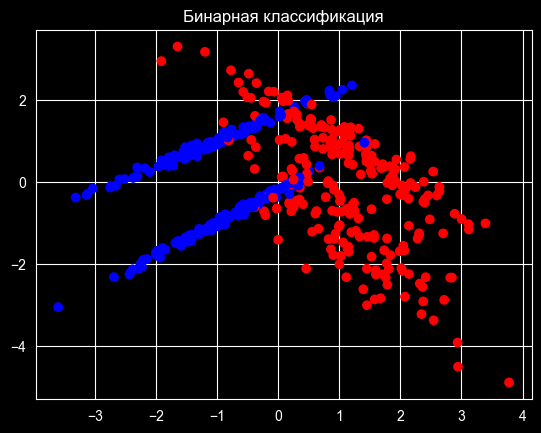

In [31]:
# Сгенерируем простой датасет для бинарной классификации
X, Y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42
)

# Визуализация
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='bwr')
plt.title("Бинарная классификация")
plt.show()

In [32]:
class LogisticRegression:
    """
    Класс реализует логистическую регрессию,
    обучаемую методом градиентного спуска.

    Модель имеет вид:
        z = Xw + b
        y_pred = sigmoid(z)

    где:
        sigmoid(z) = 1 / (1 + exp(-z))

    В отличие от линейной регрессии:
        - предсказывается не число, а вероятность
        - используем log loss (а не MSE)
    """

    def __init__(self, learning_rate: float = 0.1, iterations: int = 1000):
        """
        Инициализация параметров модели

        Параметры:
            learning_rate: скорость обучения (eta)
            iterations: количество итераций
        """
        self.learning_rate = float(learning_rate)
        self.iterations = int(iterations)

        # Параметры модели
        self.weights: np.ndarray | None = None
        self.bias: float = 0.0

        # Данные
        self.X: np.ndarray | None = None
        self.Y: np.ndarray | None = None

        # История функции потерь
        self.loss_history: list[float] = []

    def sigmoid(self, z):
        """
        Сигмоида превращает любое число в диапазон [0, 1]
        Дает вероятность принадлежности к классу 1.
        """
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, Y, Y_pred):
        """
        Логистическая функция потерь (Binary Cross Entropy)

        Формула:
            L = -1/m * Σ [y log(p) + (1 - y) log(1 - p)]

        Обоснование:
            - MSE плохо работает для вероятностей
            - Однако, Binary Cross Entropy дает правильные градиенты

        Добавляем eps для защиты от log(0)
        """
        m = Y.shape[0]
        eps = 1e-15

        Y_pred = np.clip(Y_pred, eps, 1 - eps)

        loss = - (1 / m) * np.sum(
            Y * np.log(Y_pred) + (1 - Y) * np.log(1 - Y_pred)
        )

        return loss

    def fit(self, X, Y):
        """
        Обучение модели

        Алгоритм:
            1. Инициализация весов
            2. На каждой итерации:
                - считаем предсказания
                - считаем loss
                - обновляем веса

        Параметры:
            X: матрица признаков (m, n)
            Y: целевая переменная (m,)
        """
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float).reshape(-1)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        m, n = X.shape

        # Инициализация
        self.weights = np.zeros(n)
        self.bias = 0.0

        self.X = X
        self.Y = Y

        for _ in range(self.iterations):
            self.update_weights()

            # Считаем loss
            predictions = self.predict_proba(X)
            loss = self.compute_loss(Y, predictions)

            self.loss_history.append(loss)

        return self

    def update_weights(self):
        """
        Один шаг градиентного спуска

        Формулы:

            z = Xw + b
            y_pred = sigmoid(z)

            dW = (1/m) * X^T (y_pred - y)
            db = (1/m) * sum(y_pred - y)

        Важно:
            отличие от линейной регрессии:
                - там ошибка = (y - y_pred)
                - здесь = (y_pred - y)
        """
        if self.X is None or self.Y is None or self.weights is None:
            raise ValueError("Сначала вызовите fit()")

        X = self.X
        Y = self.Y
        m = X.shape[0]

        # Предсказания
        z = X @ self.weights + self.bias
        Y_pred = self.sigmoid(z)

        # Градиенты
        dW = (1 / m) * (X.T @ (Y_pred - Y))
        db = (1 / m) * np.sum(Y_pred - Y)

        # Обновление весов
        self.weights -= self.learning_rate * dW
        self.bias -= self.learning_rate * db

        return self.weights, self.bias

    def predict_proba(self, X):
        """
        Возвращает вероятности принадлежности к классу 1.
        """
        if self.weights is None:
            raise ValueError("Сначала обучите модель")

        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        z = X @ self.weights + self.bias
        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):
        """
        Делает финальное предсказание класса

        Если вероятность >= threshold -> класс 1,
        иначе -> класс 0.
        """
        probs = self.predict_proba(X)
        return (probs >= threshold).astype(int)

In [33]:
# Делим данные
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Создаем модель
model = LogisticRegression(learning_rate=0.1, iterations=1000)

# Обучаем
model.fit(X_train, Y_train)

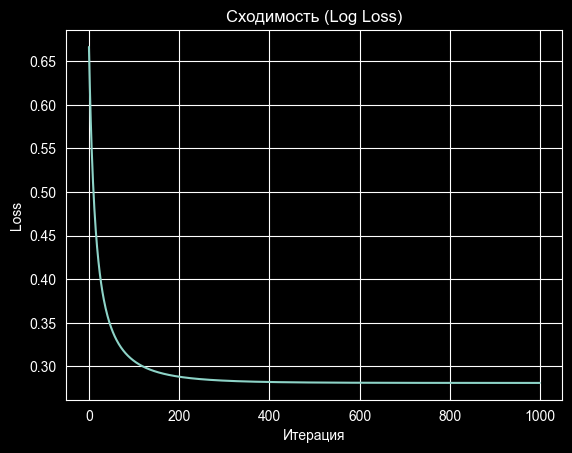

In [34]:
# Сходимость
plt.plot(model.loss_history)
plt.title("Сходимость (Log Loss)")
plt.xlabel("Итерация")
plt.ylabel("Loss")
plt.show()

In [35]:
# Оценка качества
Y_pred = model.predict(X_test)

accuracy = np.mean(Y_pred == Y_test)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.880


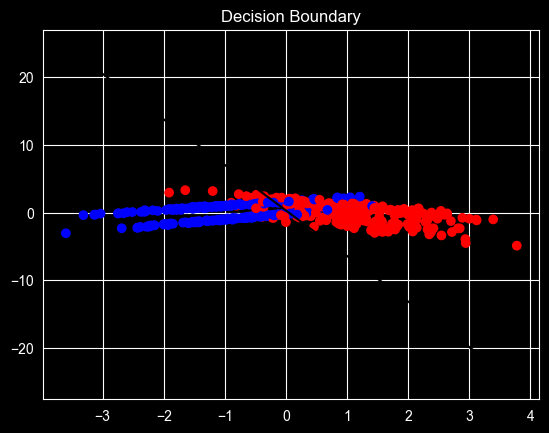

In [36]:
# Decision Boundary (граница/прямая, которая разделяет классы, предсказанные моделью)
def plot_decision_boundary(X, Y, model):
    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='bwr')

    x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    x2 = -(model.bias + model.weights[0] * x1) / model.weights[1]

    plt.plot(x1, x2, color='black')
    plt.title("Decision Boundary")
    plt.show()


plot_decision_boundary(X, Y, model)

# Реализация логистической регрессии через sklearn

In [37]:
# Обучение модели
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

model = LogisticRegression()
# Без bias (смещения)
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
# Предсказание
y_pred_sklearn = model.predict(X_test)

In [39]:
# Метрики
acc = accuracy_score(Y_test, y_pred_sklearn)
cm = confusion_matrix(Y_test, y_pred_sklearn)

print(f"Accuracy: {acc:.3f}")
print("Confusion Matrix:")
print(cm)

Accuracy: 0.880
Confusion Matrix:
[[42  8]
 [ 4 46]]


### Результат
- accuracy = (TP + TN) / все = (42 + 46) / 100 = 88 / 100 = 0.88
- Более 50% -> хорошо

- TN (True Negative) = 42
- FN (False Negative) = 4
- TP (True Positive) = 46
- FP (False Positive) = 8

### Дополнительные вопросы

1. Как влияет eta (learning rate)?
- слишком маленький -> очень медленно сходится
- слишком большой -> может разойтись (loss скачет)
- оптимум: быстро падает и стабилизируется

2. Что если мало или много итераций?
- мало -> недообучение
- много:
    - либо норм
    - либо лишние вычисления
    - либо переобучение (если noisy данные)